| First Name | Last Name |  MtkNr.  |Due Date  |
|:----------:|:---------:|:--------:|:--------:|
|   Lukas    |   Steu    | 51843919 | 24.11.2025, 16:00

<h1 style="color:rgb(150,100,10)">Computer Vision Course</h1>
<h2 style="color:rgb(150,100,10)">Assignment 2 – Feature Extraction and Segmentation </h2>

<b>Authors:</b> O. Bimber, M. Abbass<br>
<b>Date:</b> 23-06-2025

<b>This file is part of the "Computer Vision Course 2025W" UE material.</b>

<h2 style="color:rgb(150,100,10)">Table of Contents</h2>
<ol>
    <a style="color:rgb(150,100,10)" href="#Feature-Extraction"><li style="font-size:large;font-weight:bold">Feature Extraction [25 points]</li></a>
    <ol style="margin-bottom:15px">
        <a style="color:rgb(150,100,10)" href="#Extracting-Feature-Maps-from-Pretrained-Torch-Models"><li style="font-size:medium">Extracting Feature Maps from Pretrained Torch Models</li></a>
        <a style="color:rgb(150,100,10)" href="#Extracting-Feature-Maps-from-a-Custom-PyTorch-Model"><li style="font-size:medium">Extracting Feature Maps from a Custom PyTorch Model</li></a>
    </ol>
    <a style="color:rgb(150,100,10)" href="#Segmentation"><li style="font-size:large;font-weight:bold">Segmentation [75 points]</li></a>
    <ol style="margin-bottom:15px">
        <a style="color:rgb(150,100,10)" href="#Preparing-the-dataset-and-our-environment"><li style="font-size:medium">Preparing the dataset and our environment</li></a>
        <a style="color:rgb(150,100,10)" href="#Apply-UNet-for-segmentation"><li style="font-size:medium">Apply UNet for segmentation</li></a>
        <a style="color:rgb(150,100,10)" href="#Apply-attention-model-(open-Task)"><li style="font-size:medium">Apply attention model (Open Task)</li></a>
    </ol>
</ol>

<h2 style="color:rgb(255,0,0)">Please be aware that in this assignment we train and evaluate some models, which requires time. Thus, please avoid submitting your assignment at the last minute</h2>

<h2 style="color:rgb(255,0,0)">Any content unrelated to the assignment, such as images, Python code (functions or classes), additional packages, or libraries, etc., will result in a deduction of 50 points.</h2>

<h1 style="color:rgb(255,0,0)">Important Note</h1>

<b>In this assignment, you may use the default parameters of any built-in function unless specified otherwise.</b>

<b style="color:rgb(255,70,0)">All cells must be executed; any unevaluated cell will not be considered, regardless of the correctness of the code.</b>

<b style="color:rgb(255,70,0)">All cells must be indexed; any non-indexed cell will not be considered.</b>

<b style="color:rgb(255,70,0)">Modifying the given code (even a single line), whether by replacing, changing, commenting, or removing, is strictly not allowed and will result in a loss of 50 points unless explicitly specified otherwise.</b>

<b style="color:rgb(255,70,0)">Redundant code, especially duplicating or copying the given code in different places, will result in a deduction of 25 points.</b>

<b style="color:rgb(255,70,0)">Importing the same packages multiple times in different cells will result in a deduction of 25 points.</b>

<b style="color:rgb(255,70,0)">All packages are imported in the first code cell. Any changes to this cell, including modifications, removals, or additions of packages or libraries, will result in a deduction of 50 points.</b>

<b>If you have GPU resources available on your machine, please utilize them; otherwise, you can use your CPU.</b>

<b>Always set the seed value to 123 unless specified otherwise.</b>

In [32]:
# Import all packages needed in this notebook.
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt

import os, time, random
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

if not os.path.exists('resources'): raise TypeError("Please create the resources folder and include all required files")
print('All necessary packages are successfully installed')

All necessary packages are successfully installed


<a name="Feature-Extraction"></a><h2>Feature Extraction</h2>

In this part, we are supposed to learn how to extract the feature maps from different models to see what the models are learning.

<a name="Extracting-Feature-Maps-from-Pretrained-Torch-Models"></a><h3>Extracting Feature Maps from Pretrained Torch Models</h3>

<b>Exercise 1.1. [2 Points]</b>

<b>Goal:</b> Use a popular model from <i><b>torchvision</b></i> and extract its feature maps.

<b>Task</b>
<ul> <li>Use <i><b>torchvision.models</b></i> to load <i><b>VGG16</b></i>.</li>
<li>Set <i><b>pretrained=True</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>The <i><b>VGG16</b></i> model is available in the <i><b>TorchVision</b></i> library.</ul>

Documentation: <i><b>VGG16 — TorchVision</b></i> is [Here](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html#torchvision.models.vgg16) </li>

In [33]:
# code goes here

# load the vgg model
vgg16 = models.vgg16(pretrained=True)
#print(vgg16)


c:\Users\Lukas\anaconda3\envs\comvision\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lukas\anaconda3\envs\comvision\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<b>Exercise 1.2. [2 Points]</b>

<b>Goal:</b> Extract the feature maps from the given model to observe what the model has learned.

<b>Task</b>
<ul> 
<li>Use the <i><b>features_Extraction</b></i> function to extract the feature maps.</li>
<li>Use the provided image <i><b>img_A2_1</b></i> located in the <i><b>resources folder</b></i>.</li>    
</ul>

<b>Hint</b>
<ul> 
<li>You need to provide both the configured model and the target image to the <i><b>features_Extraction</b></i> function.</li>
</ul>

In [34]:
def features_Extraction(input_model, input_Image):
    input_model.eval()
    layer_to_hook = input_model.features[0]
    
    feature_maps = []
    def hook_fn(module, input, output):
        feature_maps.append(output.detach())
    hook = layer_to_hook.register_forward_hook(hook_fn)
    transform = transforms.Compose([ transforms.Resize((224, 224)), transforms.ToTensor() ])
    img = Image.open(input_Image)
    input_tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        _ = input_model(input_tensor)
    hook.remove()
    print("Shape of feature maps:", feature_maps[0].shape)
    
    return feature_maps

In [35]:
# code goes here

# get the image path
image_path = 'resources/img_A2_1.jpg'

# extract the features
featuremaps = features_Extraction(vgg16, image_path)



Shape of feature maps: torch.Size([1, 64, 224, 224])


<b>Exercise 1.3. [1 Points]</b>

<b>Goal:</b> Visualize the feature maps to understand what the model learns

<b>Task</b>
<ul>
<li>Use the function <i><b>visualize_Features</b></i> to visualize the feature maps.<i>
<li>The number of feature maps displayed should be arranged in a grid of <i><b>3 rows</b></i> rows and <i><b>4 columns</b></i>.<i>   
</ul>

<b>Hint</b>
<ul>
<li>The <i><b>visualize_Features</b></i> function accepts three attributes: the <i><b>feature maps</b></i> themselves, and the <i><b>number of rows and columns</b></i> to display.</li> 
</ul>

In [36]:
def visualize_Features(feature_maps_toShow, nu_Rows=1, nu_Columns=1):
    fm = feature_maps_toShow[0][0]
    fig, ax = plt.subplots(nu_Rows, nu_Columns, figsize=(10,9))
    for ix, axis in enumerate(ax.flat):
        axis.set_title('Filter: '+str(ix))
        axis.imshow(fm[ix].cpu())
    plt.tight_layout()
    plt.show()

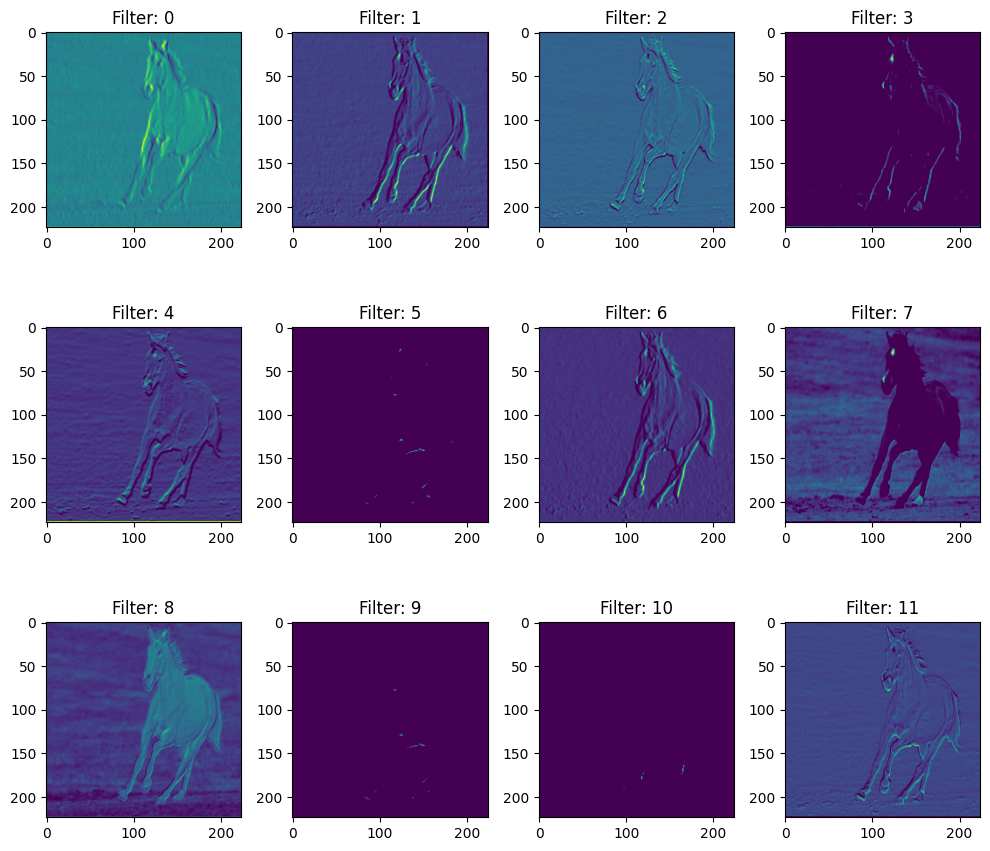

In [37]:
# code goes here

# visualize the feature
visualize_Features(featuremaps, nu_Rows=3, nu_Columns=4)


<a name="Extracting-Feature-Maps-from-a-Custom-PyTorch-Model<"></a><h3>Extracting Feature Maps from a Custom PyTorch Model</h3>

<b>Exercise 1.4. [4 Points]</b>

<b>Goal:</b> Prepare a custom model and extract the feature maps from it.

<b>Task</b>
<ul>

<li>Complete the cell below to create a custom model  as follows: 
<ol>
  <li><i><b>Conv2d</b></i> layer with <i><b>3 input channels</b></i>, <i><b>16 output channels</b></i>, and a <i><b>kernel size of 5</b></i>.</li>
  <li><i><b>ReLU</b></i> layer and <i><b>inplace is True</b></i>.</li>
  <li><i><b>Conv2d</b></i> layer with <i><b>3 output channels</b></i>, and a <i><b>kernel size of 5</b></i>.</li>
  <li><i><b>ReLU</b></i> layer and <i><b>inplace is True</b></i>.</li>
  <li><i><b>MaxPool2d</b></i> layer and <i><b>kernel_size is 2</b></i></li>
</ol>
</ul>

<b>Hint</b>
<ul>
<li>For simplicity, we create a few layers. However, you can extend the idea by creating more than these layers and extracting whichever maps you require after the training is done.</li>    
</ul>

Documentations are as follows: <i><b>Conv2d</b></i> is [Here](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) </li>, <i><b>ReLU</b></i> is [Here](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html) </li>, and <i><b>MaxPool2d</b></i> is [Here](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) </li>

In [38]:
model_Custom_Ex14 = nn.Sequential(
    
    # code goes here

    # execute the functions
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5),
    nn.ReLU(inplace=True),
    # take the in channels from the former out channels
    nn.Conv2d(in_channels=16,out_channels=3, kernel_size=5),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2)
   
                 
)

<b>Exercise 1.5. [1 Points]</b>

<b>Goal:</b> Extract the feature map from a custom model.

<b>Task</b>
<ul> 
<li>Use the <i><b>custom_Features_Extraction</b></i> function to extract the feature maps.</li>    
<li>Use the same provided image <i><b>img_A2_1</b></i> from the <i><b>resources folder</b></i>.</li>
<li>Pass the custom <i><b>model</b></i> created in <i><b>Ex 1.4</b></i> to the <i><b>custom_Features_Extraction</b></i> function.</li>
</ul>

<b>Hint</b>
<ul> 
<li>You need to provide both the custom model and our selected image as arguments to the <i><b>custom_Features_Extraction</b></i> function.</li>   
</ul>

In [39]:
def custom_Features_Extraction(model_Custom_toExtract, ip_Img_CustomModel, id_intended=0):
    feature_maps = {}
    def get_feature_map(name):
        def hook(model, input, output):
            feature_maps[name] = output.detach()
        return hook

    for idx, layer in enumerate(model_Custom_toExtract):
        if id_intended ==idx:
            layer.register_forward_hook(get_feature_map(f"conv_{idx}"))
    
    transform = transforms.Compose([ transforms.Resize((224, 224)), transforms.ToTensor()])
    img = Image.open(ip_Img_CustomModel)
    input_tensor = transform(img).unsqueeze(0)
    print(input_tensor.shape)
    _ = model_Custom_toExtract(input_tensor)

    return feature_maps

In [40]:
# code goes here

# extract features of the custom model
custom_Features_Extraction(model_Custom_Ex14, image_path)




torch.Size([1, 3, 224, 224])


{'conv_0': tensor([[[[0.5440, 0.5424, 0.5449,  ..., 0.5280, 0.5292, 0.5298],
           [0.5485, 0.5450, 0.5429,  ..., 0.5312, 0.5293, 0.5331],
           [0.5525, 0.5504, 0.5479,  ..., 0.5290, 0.5272, 0.5316],
           ...,
           [0.5563, 0.5444, 0.5434,  ..., 0.5332, 0.5336, 0.5430],
           [0.5576, 0.5524, 0.5540,  ..., 0.5357, 0.5352, 0.5395],
           [0.5582, 0.5592, 0.5573,  ..., 0.5381, 0.5331, 0.5357]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.

<b>Exercise 1.6. [15 Points]</b>

<b>Question</b>
<ul> 
<li>Q1) Let's assume that the custom model created in Ex. 1.4 will be trained on specific data and we set up the optimizer and the loss function. What steps are required in Ex. 1.4 to maintain spatial details and avoid vanishing gradients?</li>
<li>Q2) Print both models (VGG16 and our custom model). What is the difference?</li>
<li>Q3) Why can't we train our custom model for both feature extraction and classification tasks?</li>
    
</ul>

<b>Hint</b>
<ul>
<li>Each question must be answered in <i><b>1~4 lines</b></i> maximum. Exceeding 4 lines may result in point deductions.</li>
</ul>

<b>The explanation goes here:</b>

A1) to maintain the details and avoid the vanishing gradients, it is important to add padding in the conv layers (-> preserve image dimensions), to use batch normalization after convolutions(-> stable gradienents), to employ skip connections and to avoid deep unnormalized stack of layers without normalizastion or pooling

A2) VGG16 is way deeper (16 layers) than the custom model, which means that VGG16 could be used for classification whereas the custom model might only be used for feature extractions

A3) The custom model lacks a fully connected (classifier) head and has no training or labeled data. Therefore it learns only low-level spatial features

In [41]:
# Code goes here ==>> for printing both models (VGG 16 and the custom model)
print(vgg16)
print(model_Custom_Ex14)



VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

<a name="Segmentation"></a><h2>Segmentation</h2>

In this part, we utilize one of the most popular techniques in image segmentation: <i><b>UNet</b></i>.

<span style="color:rgb(200,100,10)">More details about UNet model can be found [Here](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28)</span>.
    

<b>The main goal in this part can be broken down into three sub-goals as follows:</b>
<ul>
<li>Split the data into three parts (train, test, validation).</li>    
<li>Train UNet to segment our object.</li>
<li>Test our trained model using the unseen test subset.</li>
</ul>

<h3 style="color:rgb(255,0,0)">Important Note</h3>
<span style="color:rgb(125,0,0)">We use one published version of UNet model. However, there are several <i><b>published models</b></i> that you can find.</span>

We use a dataset containing one class, which is: <span style="color:rgb(200,0,200)">Blood vessel pixels</span>. <span style="color:rgb(200,100,10)">More details about the dataset can be found [Here](https://www.kaggle.com/datasets/abdallahwagih/retina-blood-vessel)</span>.

<a name="Here is the example of crack segmentation"></a><h3 style="color:rgb(100,0,200)">Here is the example of Retina Blood segmentation from the site of [kaggle](https://www.kaggle.com/datasets/abdallahwagih/retina-blood-vessel)</h3>
<img src="resources/Example_Retina-Blood-A2.jpg" alt="Image not found!"/>

<h3 style="color:rgb(150,75,0)">Let's work on our dataset and its preparation:</h3>
<ul> <li><span style="color:rgb(180,40,40)">The dataset, named <i><b>Retina-Blood-A2</b></i>, is zipped in <i><b>resources</b></i> folder and contains two subfolders: images and masks.</span> 

<a name="Preparing-the-dataset-and-our-environment"></a><h3>Preparing the dataset and our environment</h3>

<b>Exercise 2.1. [1 Points]</b>

<b>Goal:</b> Read all images and their corresponding masks.

<b>Task</b>
<ul>
<li>Run the given function <i><b>segmDataset</b></i> to read all data and convert them to tensors.<i>
<li>You need to provide the correct <i><b>path of the data</b></i>.</li> 
</ul>

<b>Hint</b>
<ul>
<li>The provided <i><b>segmDataset</b></i> function already converts the images and their corresponding masks to tensors.</li>
<li>You must <i><b>unzip</b></i> the dataset folder <i><b>Retina-Blood-A2</b></i> and place the unzipped folder inside the resources directory.</li>
</ul>

In [42]:
class segmDataset(Dataset):
    def __init__(self, root_path, resize_IMG_MASK=320):  
        self.root_path = root_path
        self.resize_IMG_MASK = resize_IMG_MASK
        self.images = sorted([self.root_path + "/images/" + i for i in os.listdir(self.root_path + "/images/" )])
        self.masks = sorted([self.root_path + "/masks/" + i for i in os.listdir(self.root_path + "/masks/")])
        self.transform = transforms.Compose([
            transforms.Resize((self.resize_IMG_MASK, self.resize_IMG_MASK)),
            transforms.ToTensor(), ])

    def __getitem__(self, index):
        img = Image.open(self.images[index]).convert("RGB")
        mask = Image.open(self.masks[index]).convert("L")
        return self.transform(img), self.transform(mask)

    def __len__(self):
        return len(self.images)

In [43]:
# code goes here

# set the dataset path (unzip folder first)
dataset_path = "resources/Retina-Blood-A2"   

# load the dataset
retina_dataset = segmDataset(root_path=dataset_path, resize_IMG_MASK=320)

# check what you did
img_tensor, mask_tensor = retina_dataset[0]
print("Dataset size:", len(retina_dataset))
print("Image tensor shape:", img_tensor.shape)
print("Mask tensor shape:", mask_tensor.shape)


Dataset size: 100
Image tensor shape: torch.Size([3, 320, 320])
Mask tensor shape: torch.Size([1, 320, 320])


<b>Exercise 2.2. [3 Points]</b>

<b>Goal:</b> Prepare a custom dataset by splitting it into three subsets: training, validation, and test.

<b>Task</b>
<ul>
<li>Split the data into <i><b>train</b></i>, <i><b>validation</b></i>, and <i><b>test</b></i> subsets with the following ratios: <i><b>80%</b></i>, <i><b>10%</b></i>, and <i><b>10%</b></i>, respectively.<i>    
<li>You must use the <i><b>random_split</b></i> function.</li> 
<li>Set the seed for the generator to <i><b>123</b></i> to ensure reproducible results.</li> 
</ul>

<b>Hint</b>
<ul>
<li>The <i><b>random_split</b></i> function is part of the <i><b>torch.utils</b></i>.</li> 
</ul>

In [44]:
# code goes here

# get the length of the dataset
total_size = len(retina_dataset)

# calculate the split lenghts
train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)
test_size  = int(0.1 * total_size)  
print(f"Total: {total_size} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

# create generator and set the seed
generator = torch.Generator().manual_seed(123)

# fill the sets with values
train_dataset, val_dataset, test_dataset = random_split(retina_dataset, [train_size, val_size, test_size], generator=generator)

# check the set sizes
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))



Total: 100 | Train: 80 | Val: 10 | Test: 10
Train samples: 80
Validation samples: 10
Test samples: 10


<b>Exercise 2.3. [3 Points]</b>

<b>Goal:</b> Prepare all subsets using the <i><b>DataLoader</b></i>. The <i><b>DataLoader</b></i> is essential for preparing the data in the proper format for training, validation, and testing.

<b>Task</b>
<ul> <li>Use the <i><b>DataLoader</b></i> for training, validation, and testing subsets.</li>
<li>Shuffle for training subset should be <i><b>True</b></i>. Other subsets are <i><b>False</b>.</li>
<li>Set the batch size to <i><b>4</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>The <i><b>DataLoader</b></i> function is part of the torch library.</ul>

In [45]:
# code goes here

# get the loaders rdy
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

# check the loaders
print("Number of batches (train):", len(train_loader))
print("Number of batches (val):", len(val_loader))
print("Number of batches (test):", len(test_loader))



Number of batches (train): 20
Number of batches (val): 3
Number of batches (test): 3


<a name="Apply-UNet-for-segmentation"></a><h3>Apply UNet for segmentation</h3>
<h4 style="color:rgb(150,75,0)">Let's create the UNet model:</h4>
<ul> <li><span style="color:rgb(10,10,10)">The main model is in the class <i><b>UNet</b></i>; however, there are several auxiliary classes.</span>

In [46]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels))
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()        
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))
        self.down4 = (Down(512, 1024 ))
        self.up1 = (Up(1024, 512 ))
        self.up2 = (Up(512, 256 ))
        self.up3 = (Up(256, 128 ))
        self.up4 = (Up(128, 64))
        self.outc = (OutConv(64, n_classes))
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits
        
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model_without_Att = UNet().to(device)

cpu


<b>Exercise 2.4. [2 Points]</b>

<b>Goal:</b> Set up the optimizer and the loss criterion.


<b>Task</b>
<ul> <li>Use the <i><b>Adam optimizer</b></i> with learning rate of <i><b>2e-4</b></i>.</li>
<li>Use <i><b>BCEWithLogitsLoss</b></i> as the loss function. </li>
</ul>

<b>Hint</b>
<ul>
<li>Both functions <i><b>(Adam optimizer and BCEWithLogitsLoss)</b></i> are available in the torch library and can be easily invoked.</ul>

More details about <i><b>BCEWithLogitsLoss</b></i> are available [here](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).  
Moreover, details about the <i><b>Adam</b></i> optimizer are available [here](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html).

In [47]:
# code goes here

# create optimizer
optimizer = torch.optim.Adam(params=model_without_Att.parameters(), lr=2e-4)

#create loss
loss = nn.BCEWithLogitsLoss()



<b>Exercise 2.5. [5 Points]</b>

<b>Goal:</b> Let's train our model using <i><b>data from the training subset</b><i>.

<b>Task</b>
<ul><li>Use the provided <i><b>training_procedure</b></i> function to train the model parameters.</li>
<li>You need to provide the defined <i><b>model</b></i>, <i><b>optimizer</b></i>, <i><b>loss function</b></i>, <i><b>training dataloader</b></i>, and <i><b>validation dataloader</b></i> to train the model.</li>
<li>Use the attribute <i><b>name_of_Model</b></i> to specify the file name for the trained model parameters.</li>
<li>Number of epochs is <i><b>10</b></i>.</li>
</ul>
    
<b>Hint</b>
<ul><li>The trained parameters are saved in the <i><b>resources</b></i> folder under your selected name with the <i><b>.pth</b></i> extension.</li>
<li>The provided <i><b>accuracy</b></i> function calculates the accuracy, keep it unchanged.</li>
<li>Run <i><b>training_procedure</b></i> and do not modify it.</li>
<li><span style="color:rgb(180,10,10)">Note that the training can take more than 6 minutes with a GPU and up to 3 hours without one (using a CPU). For example, my GPU completed the training in about 3–5 minutes, while my CPU took approximately 2~3 hours.</span></li>

</ul>

In [48]:
def accuracy(pred, target):
    pred = (torch.sigmoid(pred) >= 0.5).view(-1)
    target = target.view(-1)
    correct = (pred == target).sum().item()
    total = target.numel()
    acc = correct / total
    return acc

def training_procedure(model_to_Training, no_Epochs, optimiz_Func, loss_Func, trainData, validData, name_of_Model : str):
    random.seed(123)    
    device_in_Train = "cuda" if torch.cuda.is_available() else "cpu"
    total_start_time = time.time()    
    for epoch in tqdm( range(no_Epochs) ):
        model_to_Training.train()
        train_running_loss, train_running_acc = 0, 0
        for idx, img_mask in enumerate(trainData):
            img = img_mask[0].float().to(device_in_Train)
            mask = img_mask[1].float().to(device_in_Train)
            
            y_pred = model_to_Training(img)
    
            loss = loss_Func(y_pred, mask)
            train_running_loss += loss.item()
        
            train_running_acc += accuracy(y_pred, mask)
        
            # Compute gradient and do optimizer step
            optimiz_Func.zero_grad()
            loss.backward()
            optimiz_Func.step()

        train_loss = train_running_loss / (idx + 1)
        train_acc = train_running_acc / (idx + 1)
        
        model_to_Training.eval()
        val_running_loss, val_running_acc = 0, 0
        with torch.no_grad():
            for idx, img_mask in enumerate((validData)):
                img = img_mask[0].float().to(device_in_Train)
                mask = img_mask[1].float().to(device_in_Train)
                
                y_pred = model_to_Training(img)
                loss = loss_Func(y_pred, mask)

                val_running_loss += loss.item()
                val_running_acc += accuracy(y_pred, mask)

            val_loss = val_running_loss / (idx + 1)
            val_acc = val_running_acc / (idx + 1)

            print("="*30)
            print(f"Train Loss EPOCH {epoch+1}: {train_loss:.4f}")
            print(f"Valid Loss EPOCH {epoch+1}: {val_loss:.4f}")
            print(f"Train accuracy EPOCH {epoch+1}: {train_acc:.4f}")
            print(f"Valid accuracy EPOCH {epoch+1}: {val_acc:.4f}")
            print("="*30)

        model_Saved_Location = f"resources/{name_of_Model}.pth"  
        torch.save(model_to_Training.state_dict(), model_Saved_Location)
        print(f"EPOCH {epoch+1} is Done")

    total_time = (time.time() - total_start_time)
    print('Total training time: {:.3f} hours'.format( ((total_time / 60)/60) ))
    print('Training Done')

    print("+"*30)
    print(f"Training Loss {train_loss:.4f}")  
    print(f"Validation Loss {val_loss:.4f}")    
    print(f"Training accuracy {train_acc:.4f}")  
    print(f"Validation accuracy {val_acc:.4f}")
    print("+"*30)

In [49]:
# code goes here

# run training
training_procedure(
    model_to_Training=model_without_Att,
    no_Epochs=10,
    optimiz_Func=optimizer,
    loss_Func=loss,
    trainData=train_loader,
    validData=val_loader,
    name_of_Model='My First Model'
)


  0%|          | 0/10 [00:00<?, ?it/s]

Train Loss EPOCH 1: 0.4795
Valid Loss EPOCH 1: 0.5267
Train accuracy EPOCH 1: 0.7764
Valid accuracy EPOCH 1: 0.7995


 10%|█         | 1/10 [08:24<1:15:40, 504.51s/it]

EPOCH 1 is Done
Train Loss EPOCH 2: 0.3658
Valid Loss EPOCH 2: 0.4374
Train accuracy EPOCH 2: 0.8087
Valid accuracy EPOCH 2: 0.7984


 20%|██        | 2/10 [16:41<1:06:38, 499.87s/it]

EPOCH 2 is Done
Train Loss EPOCH 3: 0.3327
Valid Loss EPOCH 3: 0.3399
Train accuracy EPOCH 3: 0.8101
Valid accuracy EPOCH 3: 0.8077


 30%|███       | 3/10 [25:14<59:02, 506.05s/it]  

EPOCH 3 is Done


 30%|███       | 3/10 [31:58<1:14:36, 639.54s/it]


KeyboardInterrupt: 

<b>Exercise 2.6. [3 Points]</b>

<b>Goal: </b>Let's load the trained model and its parameters. Now, we can use the trained model to predict and segment <i><b>blood vessels</b><i> <i><b>using unseen data from the test subset</b><i>.


<b>Task</b>
<ul> <li>Call the model <i><b>UNet</b></i> again, and keep the model on your <i><b>CPU</b></i>.</li>
<li>Use the <i><b>load_state_dict</b></i> function to load the trained model parameters.</li>
<li>Set the <i><b>map_location</b></i> parameter to <i><b>CPU</b></i> when loading the model.</li></ul>

<b>Hint</b>
<ul><li>The trained parameters are located in the <i><b>resources</b></i> folder under your selected name with the <i><b>.pth</b></i> extension.</ul>

In [ ]:
# code goes here

# call the model again and keep it on the cpu
UNet = UNet()
device = torch.device("cpu")
UNet.to(device)

# load the trained parameters
model_path = "resources/My First Model.pth"

UNet.load_state_dict(torch.load(model_path, map_location=device))
UNet.eval()

print("✅ Model loaded successfully on CPU and ready for inference.")


✅ Model loaded successfully on CPU and ready for inference.


<b>Exercise 2.7. [3 Points]</b>

<b>Goal:</b> Now, we use the trained model to segment the <i><b>retina blood vessels</b><i>  based on <i><b>unseen data</b><i> from the <i><b>test subset</b><i>.

<b>Task</b>
<ul> <li>Use the <i><b>test_procedure</b></i> function to segment the test data.</li>
<li>Provide the <i><b>trained model</b></i> and the <i><b>test dataloader</b></i> as inputs.</li>
<li>Display the first batch in a grid with <i><b>4</b></i> rows and <i><b>3</b></i> columns.</li>
<li>The grid should display the following in order: the <i><b>RGB image</b></i>, the <i><b>ground truth</b></i>, and the <i><b>predicted segmented image</b></i>.</li>
<li>The <i><b>colormap</b></i> of the <i><b>imshow</b></i> or <i><b>displayed images</b></i> should be <i><b>gray</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>The <i><b>test_procedure</b></i> function returns three outputs: the RGB image, the ground truth, and the predicted segmented image.</li>
<li>For simplicity, the <i><b>test_procedure</b></i> function returns only one batch</li>
</ul>

In [ ]:
def test_procedure(model_to_Test, testData):
    with torch.no_grad():
        for idx, img_mask in enumerate((testData)):
            img = img_mask[0].to('cpu')
            mask = img_mask[1].to('cpu')
            pred_mask = torch.sigmoid( model_to_Test(img) )
            if idx==0:
                break
        return img, mask, pred_mask

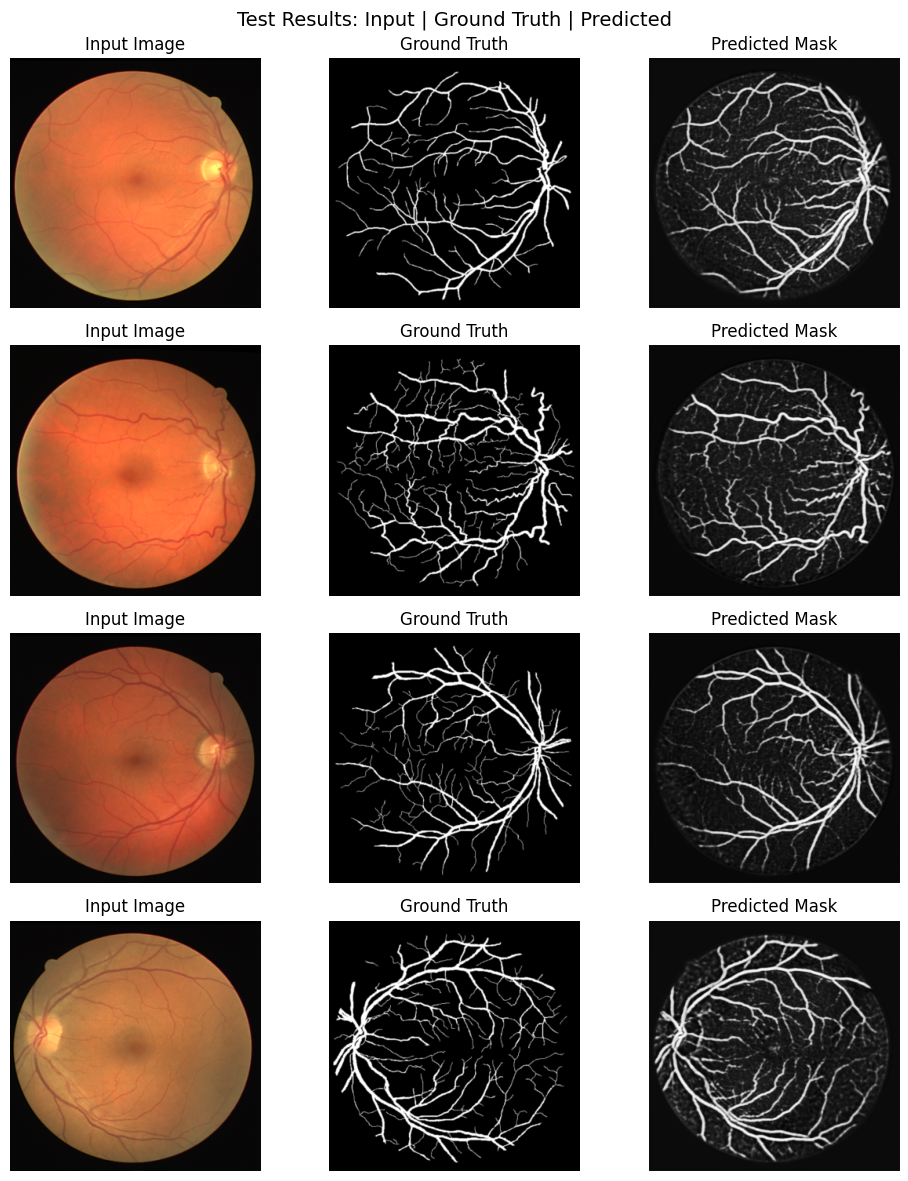

In [ ]:
# code goes here

# use the test procedure func
test_images, test_masks, test_pred_masks = test_procedure(UNet, test_loader)


# visualize the resultr (4 rows × 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("Test Results: Input | Ground Truth | Predicted", fontsize=14)

for i in range(4):  # 4 rows
    # RGB input
    axes[i, 0].imshow(test_images[i].permute(1, 2, 0))  # CHW → HWC
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    # ground truth
    axes[i, 1].imshow(test_masks[i][0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # prediction
    axes[i, 2].imshow(test_pred_masks[i][0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

<a name="Apply-attention-model-(open-Task)"></a><h3>Apply attention model (Open Task)</h3>

<b>Exercise 2.8. [3 Points]</b>

<b>Goal:</b> Enhance the model by adding an attention mechanism.

<b>Task</b>
<ul>
<li>Use the attention model defined in the class <i><b>att_Model</b></i>.</li>
<li>For simplicity, a class named <i><b>UNet_Att</b></i> has been created for you. Insert the attention model into the <i><b>UNet_Att</b></i> model.</li>
</ul>
    
<b>Hint</b>
<ul>
<li>This is an open task. You may choose the locations and the number of insertions. It is also possible to insert the attention model in a single location.</li>
<li><span style="color:rgb(180,10,10)">You can modify the <i>reduction</i> attribute in the <i>att_Model</i> if needed.</span></li>
<li><span style="color:rgb(190,48,48)">Don’t change the name of the class <i><b>UNet_Att</b></i>.</span></li>
<li><span style="color:rgb(180,10,10)"><i><b>model_Att</b></i> is used as a different object name, keep it unchanged.</span></li>
</ul>
    
<span style="color:rgb(200,100,10)">For your reference, the paper link for this attention mechanism is: [Here](https://arxiv.org/pdf/1709.01507)</span> </li>

In [ ]:
class att_Model(nn.Module):
    def __init__(self, channel, reduction=1):
        super(att_Model, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False), nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, w, h = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels))
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()        
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet_Att(nn.Module):
    
    # code goes here

    # define the initialization
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet_Att, self).__init__()

        # encoder (downsampling)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        # bottleneck
        self.down4 = Down(512, 1024)

        # decoder (upsampling)
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        # output
        self.outc = OutConv(64, n_classes)

        # attention modules (optional insertion points)
        self.att1 = att_Model(1024)
        self.att2 = att_Model(512)
        self.att3 = att_Model(256)

    def forward(self, x):
        # encoder path
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # apply attention to deeper feature maps (decoder input)
        x5 = self.att1(x5)
        x4 = self.att2(x4)
        x3 = self.att3(x3)

        # decoder path
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)

        return logits
   
        
        
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model_Att = UNet_Att().to(device)

cpu


<b>Exercise 2.9. [1 Points]</b>

<b>Goal:</b> Now, print the model after adding the attention mechanism.

<b>Task</b>
<ul>
<li>Print <i><b>model_Att</b></i>.</li>

</ul>
    
<b>Hint</b>
<ul>
<li>Make sure that the cell containing <i><b>model_Att</b></i> has been executed.</li>
</ul>

In [ ]:
# code goes here

print(model_Att)


UNet_Att(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fals

<b>Exercise 2.10. [8 Points]</b>

<b>Goal:</b> Train and test our new model using the attention mechanism.

<b>Task</b>
<ul>
<li>Use the provided <i><b>training_procedure</b></i> function to train the model <i><b>UNet_Att</b></i> created in <i><b>Exercise 2.8.</b></i> with the attention mechanism.</li>
<li>Keep all attributes unchanged, including the number of epochs, optimizer, loss function, training dataloader, and validation dataloader.</li>
<li>Within the <i><b>training_procedure</b></i> function, update the name of the newly trained model parameters to reflect the attention mechanism.</li> 
<li>Repeat <i><b>Exercises 2.6 and 2.7</b></i> using the model created in <i><b>Exercise 2.8</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li><span style="color:rgb(180,10,10)">Rewrite the <i>optimizer</i> to reflect the parameters of the newly trained model.</span></li>
<li><span style="color:rgb(180,10,10)">Use the <i><b>BCEWithLogitsLoss</b></i> variable as the loss function from Exercise 2.4 (don’t rewrite the loss function). Rewriting it will result in a deduction of points.</span></li>
<li><span style="color:rgb(180,10,10)">All necessary functions defined above must be called without copying them again. Otherwise, points will be deducted.</span></li>
</ul>

In [ ]:
# code goes here

# just only train a new optimizer
optimizer_Att = torch.optim.Adam(model_Att.parameters(), lr=0.001)

# train the model with almost the exact same paramas as in exercise 2.5
training_procedure(
    model_to_Training=model_Att,
    no_Epochs=10,
    optimiz_Func=optimizer_Att, #new
    loss_Func=loss,             
    trainData=train_loader,
    validData=val_loader,
    name_of_Model="UNet_AttentionModel"  
)


  0%|          | 0/10 [00:00<?, ?it/s]

Train Loss EPOCH 1: 0.3784
Valid Loss EPOCH 1: 0.4051
Train accuracy EPOCH 1: 0.7876
Valid accuracy EPOCH 1: 0.7995


 10%|█         | 1/10 [03:10<28:38, 190.96s/it]

EPOCH 1 is Done


 20%|██        | 2/10 [06:33<26:20, 197.61s/it]

...

Train Loss EPOCH 9: 0.1372
Valid Loss EPOCH 9: 0.1534
Train accuracy EPOCH 9: 0.8135
Valid accuracy EPOCH 9: 0.8091
EPOCH 9 is Done


100%|██████████| 10/10 [45:26<00:00, 239.26s/it]

Train Loss EPOCH 10: 0.1345
Valid Loss EPOCH 10: 0.1410
Train accuracy EPOCH 10: 0.8134
Valid accuracy EPOCH 10: 0.8098
EPOCH 10 is Done


100%|██████████| 10/10 [45:26<00:00, 272.63s/it]

Total training time: 0.757 hours
Training Done
++++++++++++++++++++++++++++++
Training Loss 0.1345
Validation Loss 0.1410
Training accuracy 0.8134
Validation accuracy 0.8098
++++++++++++++++++++++++++++++


✅ Attention U-Net loaded on CPU and ready for testing.


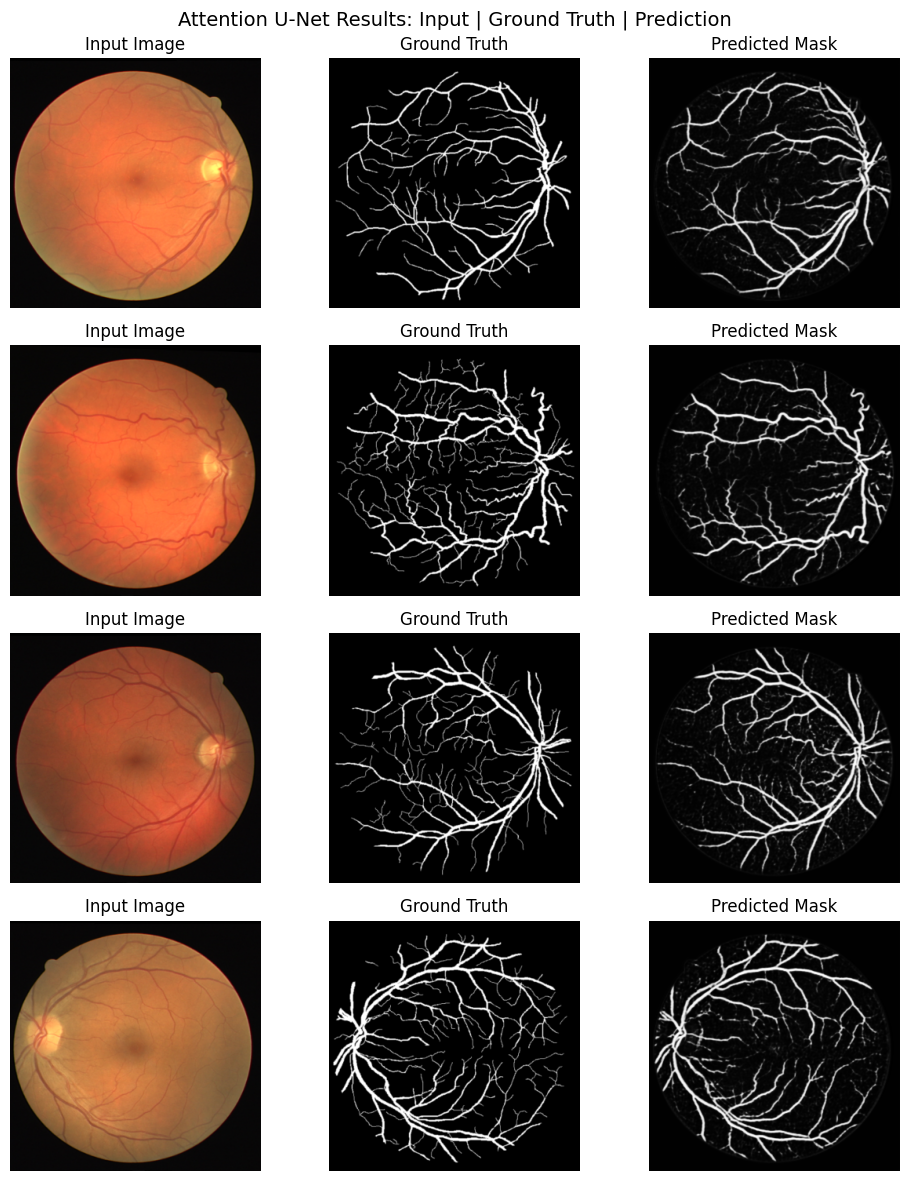

In [ ]:
model_Att_CPU = UNet_Att()
model_Att_CPU.load_state_dict(
    torch.load("resources/UNet_AttentionModel.pth", map_location="cpu")
)
model_Att_CPU.eval()

print("✅ Attention U-Net loaded on CPU and ready for testing.")

# test procedure – segment retina vessels
test_images, test_masks, test_preds = test_procedure(model_Att_CPU, test_loader)

# visualization (4×3 Grid)
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("Attention U-Net Results: Input | Ground Truth | Prediction", fontsize=14)

for i in range(4):
    axes[i, 0].imshow(test_images[i].permute(1, 2, 0))
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(test_masks[i][0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(test_preds[i][0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

<b>Exercise 2.11. [10 Points]</b>

<b>Goal:</b> Train and test the model using your attention mechanism.

<b>Task</b>
<ul>
<li>Defined your attention model in the class <i><b>your_Att_Model</b></i>. <span style="color:rgb(180,10,10)">You must select a different attention model than the one used in <i><b>Exercise 2.8</b></i>.</span></li>
<li>For simplicity, a class named <i><b>your_UNet_Att</b></i> has also been created for you. Insert your defined attention model into the <i><b>your_UNet_Att</b></i> model.</li>
<li>Print <i><b>your_UNet_Att</b></i>.</li>
<li>Use the provided <i><b>training_procedure</b></i> function to train the <i><b>your_UNet_Att</b></i> model.</li>
<li>Keep all attributes unchanged, including the number of epochs, optimizer, loss function, training dataloader, and validation dataloader.</li>
<li>Within the <i><b>training_procedure</b></i> function, update the name of the newly trained model parameters to reflect the attention mechanism.</li> 
<li>Repeat <i><b>Exercises 2.6 and 2.7</b></i> using the <i><b>your_UNet_Att</b></i> model.</li>
</ul>

<b>Hint</b>
<ul>
<li><span style="color:rgb(190,48,48)"><i><b>your_Model_Att</b></i> is used as a different object name, keep it unchanged.</span></li>
<li><span style="color:rgb(190,48,48)">Don’t change the name of the class <i><b>your_UNet_Att</b></i>.</span></li>
<li><span style="color:rgb(190,48,48)">Rewrite the <i>optimizer</i> to reflect the parameters of the newly trained model.</span></li>
<li><span style="color:rgb(190,48,48)">Use the <i><b>BCEWithLogitsLoss</b></i> variable as the loss function from Exercise 2.4 (don’t rewrite the loss function). Rewriting it will result in a deduction of points.</span></li>
<li><span style="color:rgb(190,48,48)">All necessary functions defined above must be called without copying them again. Otherwise, points will be deducted.</span></li>
</ul>

In [ ]:
class your_Att_Model(nn.Module):
    
    # code goes here

    def __init__(self, kernel_size=7):
        super(your_Att_Model, self).__init__()
        padding = kernel_size // 2
        # it is wokred on two channels: [avg_pool, max_pool] → 1-channel-Attention
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, H, W]
        avg_out = torch.mean(x, dim=1, keepdim=True)         # [B, 1, H, W]
        max_out, _ = torch.max(x, dim=1, keepdim=True)       # [B, 1, H, W]
        att = torch.cat([avg_out, max_out], dim=1)           # [B, 2, H, W]
        att = self.conv(att)                                 # [B, 1, H, W]
        att = self.sigmoid(att)                              # [0,1]
        return x * att                                       # spatial weighted
    



class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels))
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()        
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class your_UNet_Att(nn.Module):
    
    # code goes here

     def __init__(self, n_channels=3, n_classes=1):
        super(your_UNet_Att, self).__init__()

        # encoder
        self.inc   = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        # decoder
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = OutConv(64, n_classes)

        # your spatial attention module on the skip feature maps
        self.att_x1 = your_Att_Model()  # on a low level
        self.att_x2 = your_Att_Model()
        self.att_x3 = your_Att_Model()
        self.att_x4 = your_Att_Model()  # on a high level

     def forward(self, x):
        # encoder path
        x1 = self.inc(x)          # [B, 64,  H,   W]
        x1 = self.att_x1(x1)

        x2 = self.down1(x1)       # [B, 128, H/2, W/2]
        x2 = self.att_x2(x2)

        x3 = self.down2(x2)       # [B, 256, H/4, W/4]
        x3 = self.att_x3(x3)

        x4 = self.down3(x3)       # [B, 512, H/8, W/8]
        x4 = self.att_x4(x4)

        x5 = self.down4(x4)       # [B, 1024, H/16, W/16] (here without attention)

        # decoder path with skip connection
        x = self.up1(x5, x4)      # uses x4 (already with attention)
        x = self.up2(x,  x3)      # uses x3
        x = self.up3(x,  x2)      # uses x2
        x = self.up4(x,  x1)      # uses x1

        logits = self.outc(x)
        return logits
   

                
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
your_Model_Att = your_UNet_Att().to(device)
print(your_Model_Att)

# change optimizer for new model
optimizer_your_Att = torch.optim.Adam(your_Model_Att.parameters(), lr=0.001)

# train 
training_procedure(
    model_to_Training=your_Model_Att,
    no_Epochs=10,                            # same epochs
    optimiz_Func=optimizer_your_Att,
    loss_Func=loss,                          # same loss as before
    trainData=train_loader,
    validData=val_loader,
    name_of_Model="your_UNet_Att_Model"      # new name
)

cpu
your_UNet_Att(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

 10%|█         | 1/10 [03:55<35:19, 235.47s/it]

Train Loss EPOCH 1: 0.4059
Valid Loss EPOCH 1: 0.4609
Train accuracy EPOCH 1: 0.7804
Valid accuracy EPOCH 1: 0.7995
EPOCH 1 is Done
Train Loss EPOCH 2: 0.2741
Valid Loss EPOCH 2: 0.3397
Train accuracy EPOCH 2: 0.8098
Valid accuracy EPOCH 2: 0.8008


 20%|██        | 2/10 [08:14<33:16, 249.53s/it]

EPOCH 2 is Done
Train Loss EPOCH 3: 0.2152
Valid Loss EPOCH 3: 0.2297
Train accuracy EPOCH 3: 0.8123
Valid accuracy EPOCH 3: 0.8063


...

Train Loss EPOCH 8: 0.1413
Valid Loss EPOCH 8: 0.1489
Train accuracy EPOCH 8: 0.8137
Valid accuracy EPOCH 8: 0.8095
EPOCH 8 is Done
Train Loss EPOCH 9: 0.1366
Valid Loss EPOCH 9: 0.1475
Train accuracy EPOCH 9: 0.8135
Valid accuracy EPOCH 9: 0.8086
EPOCH 9 is Done


100%|██████████| 10/10 [42:01<00:00, 238.53s/it]

Train Loss EPOCH 10: 0.1339
Valid Loss EPOCH 10: 0.1390
Train accuracy EPOCH 10: 0.8138
Valid accuracy EPOCH 10: 0.8101
EPOCH 10 is Done


100%|██████████| 10/10 [42:01<00:00, 252.19s/it]

Total training time: 0.701 hours
Training Done
++++++++++++++++++++++++++++++
Training Loss 0.1339
Validation Loss 0.1390
Training accuracy 0.8138
Validation accuracy 0.8101
++++++++++++++++++++++++++++++


✅ your_UNet_Att loaded on CPU.


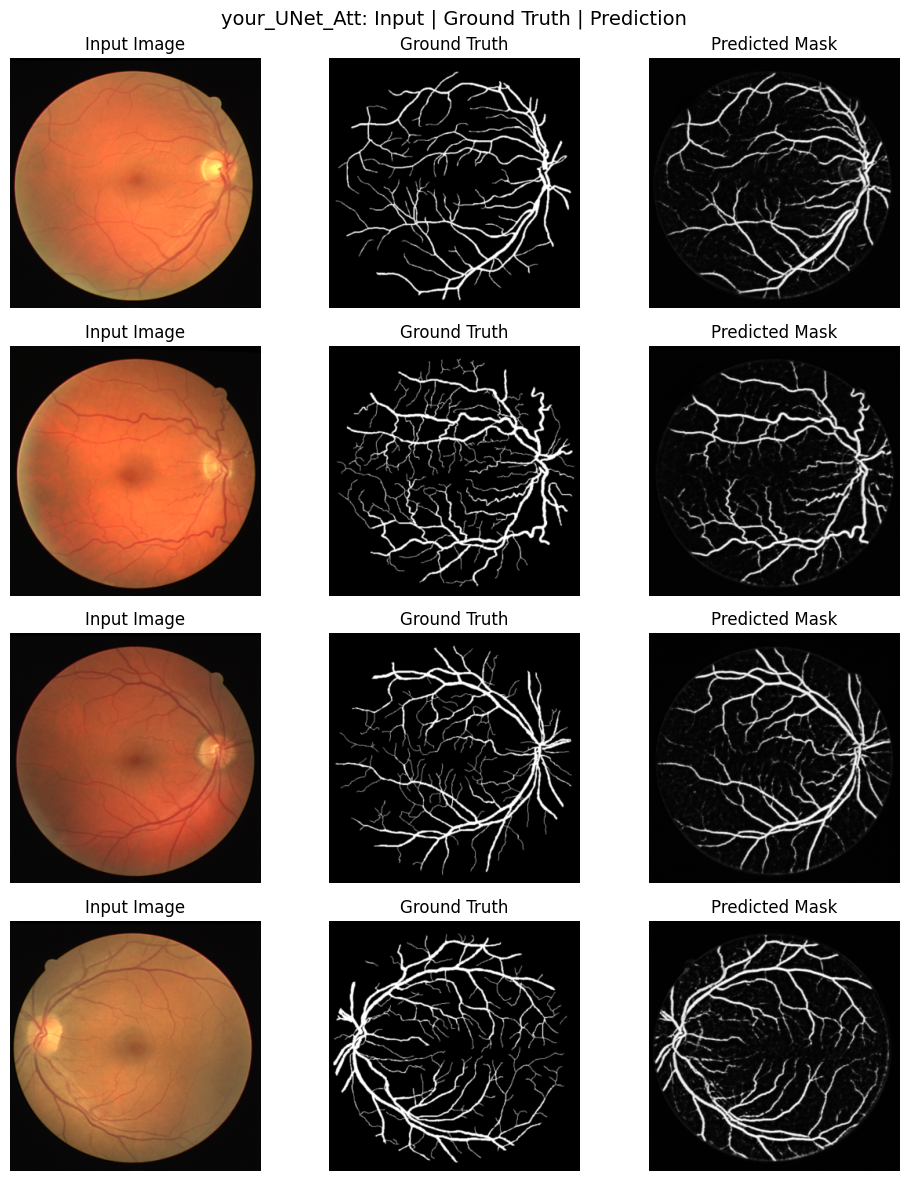

In [ ]:
# code goes here

# load model on the cpu
your_Model_Att_CPU = your_UNet_Att()
your_Model_Att_CPU.load_state_dict(
    torch.load("resources/your_UNet_Att_Model.pth", map_location="cpu")
)
your_Model_Att_CPU.eval()
print("✅ your_UNet_Att loaded on CPU.")

# test the first batch of the test loader
test_images, test_masks, test_preds = test_procedure(your_Model_Att_CPU, test_loader)

# visualize the results
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("your_UNet_Att: Input | Ground Truth | Prediction", fontsize=14)

for i in range(4):
    # RGB input 
    axes[i, 0].imshow(test_images[i].permute(1, 2, 0))
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    # ground truth
    axes[i, 1].imshow(test_masks[i][0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    # prediction
    axes[i, 2].imshow(test_preds[i][0], cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


<b>Exercise 2.12. [16 Points]</b>

<b>Goal:</b> Train and test the model using provied and your attention mechanism.

<b>Task</b>
<ul>
<li>insert <i><b>your attention model</b></i> in the <i><b>Exercises 2.11</b></i> and the provied model in the <i><b>Exercises 2.8</b></i> in the class <i><b>combined_UNet_Att</b></i>.</li>
<li>For simplicity, a class named <i><b>combined_UNet_Att</b></i> has also been created for you. Insert both attention models into the <i><b>combined_UNet_Att</b></i> model.</li>
<li>Print <i><b>combined_Model_Att</b></i>.</li>
<li>Use the provided <i><b>training_procedure</b></i> function to train <i><b>combined_UNet_Att</b></i> model.</li>
<li>Keep all attributes unchanged, including the number of epochs, optimizer, loss function, training dataloader, and validation dataloader.</li>
<li>Within the <i><b>training_procedure</b></i> function, update the name of the newly trained model parameters to reflect the all attention models.</li> 
<li>Repeat <i><b>Exercises 2.6 and 2.7</b></i> using the <i><b>combined_UNet_Att</b></i> model.</li>
</ul>

<b>Hint</b>
<ul>
<li><span style="color:rgb(190,48,48)"><i><b>combined_Model_Att</b></i> is used as a different object name, keep it unchanged.</span></li>
<li><span style="color:rgb(190,48,48)">Don’t change the name of the class <i><b>combined_UNet_Att</b></i>.</span></li>
<li><span style="color:rgb(190,48,48)">Rewrite the <i>optimizer</i> to reflect the parameters of the newly trained model.</span></li>
<li><span style="color:rgb(190,48,48)">Use the <i><b>BCEWithLogitsLoss</b></i> variable as the loss function from Exercise 2.4 (don’t rewrite the loss function). Rewriting it will result in a deduction of points.</span></li>
<li><span style="color:rgb(190,48,48)">All necessary functions defined above must be called without copying them again. Otherwise, points will be deducted.</span></li>
</ul>

In [31]:
class your_Att_Model(nn.Module):
    
    # code goes here ==>> should be same as Exercise 2.11.

    def __init__(self, kernel_size=7):
        super(your_Att_Model, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        att = torch.cat([avg_out, max_out], dim=1)
        att = self.conv(att)
        att = self.sigmoid(att)
        return x * att
    
    

     


class att_Model(nn.Module):
    def __init__(self, channel, reduction=1):
        super(att_Model, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False), nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, w, h = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)
    

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels))
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()        
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class combined_UNet_Att(nn.Module):
    
    # code goes here

    def __init__(self, n_channels=3, n_classes=1):
        super(combined_UNet_Att, self).__init__()

        # encoder
        self.inc   = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        # decoder
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = OutConv(64, n_classes)

        # attention
        # your spatial attention (low-level)
        self.att_x1 = your_Att_Model()
        self.att_x2 = your_Att_Model()
        self.att_x3 = your_Att_Model()

        # provided channel attention (high-level)
        self.att_x4 = att_Model(512)
        self.att_x5 = att_Model(1024)

    def forward(self, x):
        # encoder
        x1 = self.inc(x)
        x1 = self.att_x1(x1)

        x2 = self.down1(x1)
        x2 = self.att_x2(x2)

        x3 = self.down2(x2)
        x3 = self.att_x3(x3)

        x4 = self.down3(x3)
        x4 = self.att_x4(x4)

        x5 = self.down4(x4)
        x5 = self.att_x5(x5)

        # Decoder (skip connections carry both att types)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits
    
    
           
        
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
combined_Model_Att = combined_UNet_Att().to(device)
print(combined_Model_Att)

# change to new optimizer
optimizer_combined = torch.optim.Adam(combined_Model_Att.parameters(), lr=0.001)

training_procedure(
    model_to_Training=combined_Model_Att,
    no_Epochs=10,
    optimiz_Func=optimizer_combined,
    loss_Func=loss,                
    trainData=train_loader,
    validData=val_loader,
    name_of_Model="combined_UNet_AllAttention"   # new name
)

cpu
combined_UNet_Att(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

 10%|█         | 1/10 [03:34<32:12, 214.71s/it]

Train Loss EPOCH 1: 0.4792
Valid Loss EPOCH 1: 0.5917
Train accuracy EPOCH 1: 0.7413
Valid accuracy EPOCH 1: 0.6460
EPOCH 1 is Done
Train Loss EPOCH 2: 0.3391
Valid Loss EPOCH 2: 0.3157
Train accuracy EPOCH 2: 0.8054
Valid accuracy EPOCH 2: 0.7995


 20%|██        | 2/10 [07:39<30:57, 232.17s/it]

EPOCH 2 is Done
Train Loss EPOCH 3: 0.2748
Valid Loss EPOCH 3: 0.2557
Train accuracy EPOCH 3: 0.8099
Valid accuracy EPOCH 3: 0.8021


...

EPOCH 8 is Done
Train Loss EPOCH 9: 0.1483
Valid Loss EPOCH 9: 0.1522
Train accuracy EPOCH 9: 0.8131
Valid accuracy EPOCH 9: 0.8095


 90%|█████████ | 9/10 [46:17<06:29, 389.73s/it]

EPOCH 9 is Done
Train Loss EPOCH 10: 0.1434
Valid Loss EPOCH 10: 0.1490
Train accuracy EPOCH 10: 0.8131
Valid accuracy EPOCH 10: 0.8078


100%|██████████| 10/10 [52:49<00:00, 316.93s/it]

EPOCH 10 is Done
Total training time: 0.880 hours
Training Done
++++++++++++++++++++++++++++++
Training Loss 0.1434
Validation Loss 0.1490
Training accuracy 0.8131
Validation accuracy 0.8078
++++++++++++++++++++++++++++++


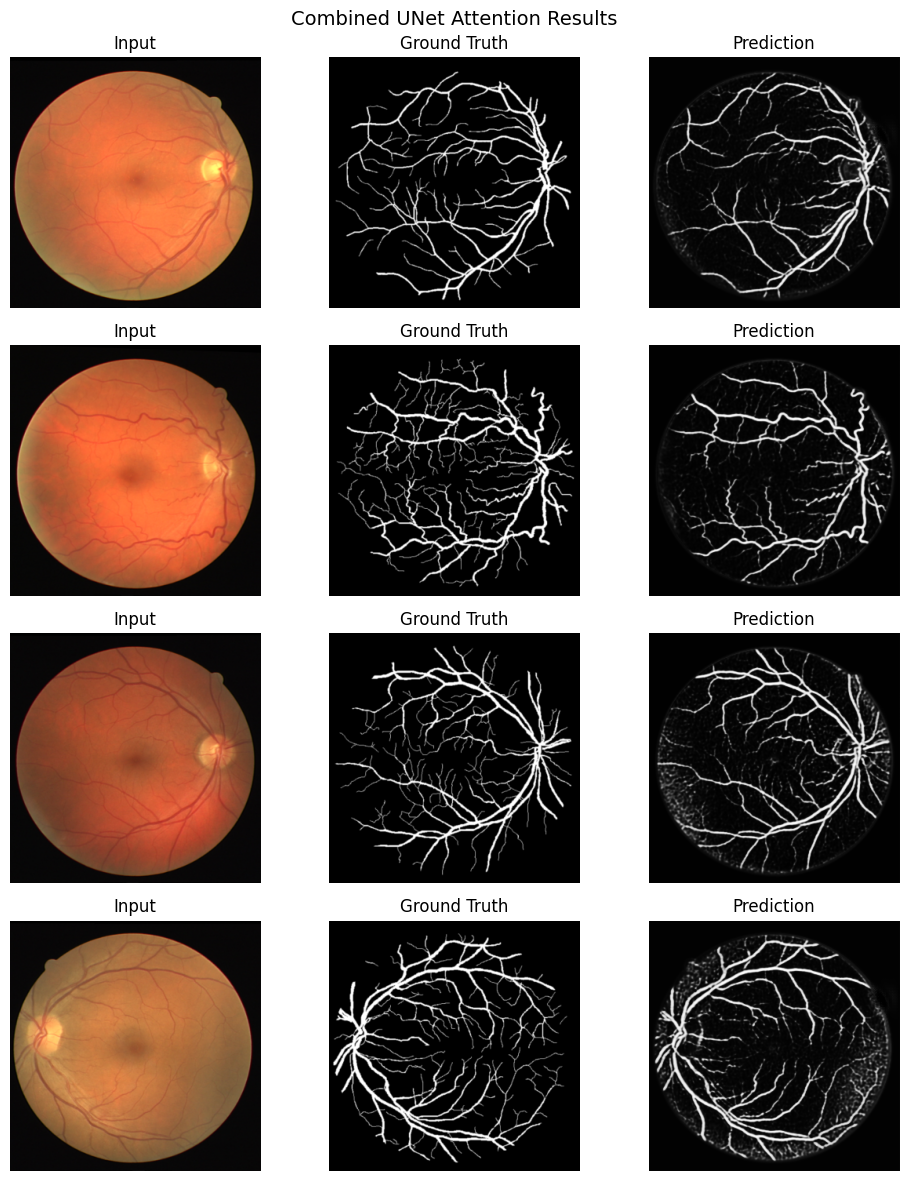

In [51]:
# code goes here

combined_Model_Att_CPU = combined_UNet_Att()
combined_Model_Att_CPU.load_state_dict(
    torch.load("resources/combined_UNet_AllAttention.pth", map_location="cpu")
)
combined_Model_Att_CPU.eval()

test_images, test_masks, test_preds = test_procedure(combined_Model_Att_CPU, test_loader)

fig, axes = plt.subplots(4, 3, figsize=(10, 12))
fig.suptitle("Combined UNet Attention Results", fontsize=14)

for i in range(4):
    axes[i, 0].imshow(test_images[i].permute(1, 2, 0))
    axes[i, 0].set_title("Input")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(test_masks[i][0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(test_preds[i][0], cmap="gray")
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()




<b>Exercise 2.13. [12 Points]</b>

<b>Question</b>
<ul> 

<li>Q1) How can we differentiate between different vessels (the main branch and sub-branches)?</li>
<li>Q2) What is the problem in our blood vessel data when we differentiate between the main branch and sub-branches?</li>
<li>Q3) What would you notice if we apply Grad-CAM?, and why?</li>
</ul>

<b>Hint</b>
<ul>
<li>Each question must be answered in <i><b>1~4 lines</b></i> maximum. Exceeding 4 lines may result in point deductions.</li>
</ul>

<b>The explanation goes here:</b>

A1) By analyzing vessel thickness, shape, and connectivity. Main vessels are usually thicker and more central, while sub-branches are thinner.

A2) The dataset has only binary labels, so all vessels look the same. The model cannot learn differences between main and small vessels.

A3) Grad-CAM will highlight all vessel pixels similarly, because the model only learns binary segmentation, not vessel importance or hierarchy.


<b>Exercise 2.14. [5 Points]</b>

<b>Question</b>
<ul> 

<li>Q1) Can you upload the Grad-CAM visualizations of our trained models based on the last layers, for all versions (without attention and with attention)?</li>
</ul>

<b>Hint</b>
<ul>
<li>You can use Pillow to read the images and imshow from Matplotlib to display them.</li>
<li>You can obtain the Grad-CAM image using any available online resource.</li>
</ul>

In [ ]:
# code goes here

#Yes. I can upload the Grad-CAM visualizations for all trained models (baseline U-Net, SE-Attention U-Net, and my own Attention U-Net). The images can be loaded with Pillow (PIL.Image.open) and displayed using Matplotlib’s imshow().
